In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy import signal

In [3]:
d = "20260313T1512-weekend-baseline"

dfs = []
for i in range(2):
    df = pd.read_csv(f"{d}/a{i+1}-data.csv")
    df = df[15:-15].copy()
    df.loc[df["Humidity (%)"] > 90, "Humidity (%)"] = np.nan
    df.loc[df["Temperature (C)"] > 25, "Temperature (C)"] = np.nan
    df.loc[df["Temperature (C)"] < 15, "Temperature (C)"] = np.nan
    df = df.dropna()
    del df["Timestamp"]
    dfs.append(df)

In [5]:
print([df["Sound"].max() for df in dfs])
print([df["Sound"].min() for df in dfs])

[np.float64(49994.43), np.float64(49999.46)]
[np.float64(0.0), np.float64(0.0)]


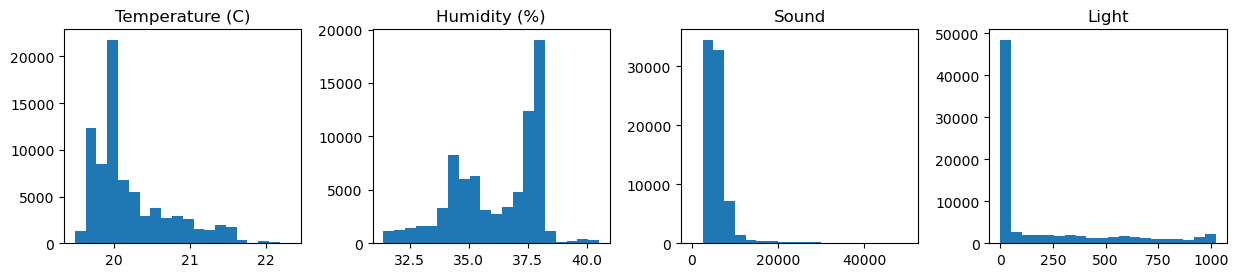

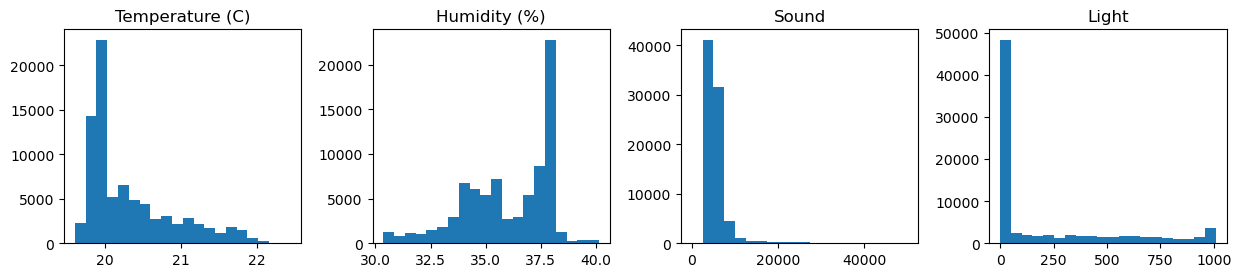

In [6]:
for df in dfs:
    df.hist(bins=20, figsize=(15, 10), layout=(3, 4), grid=False)

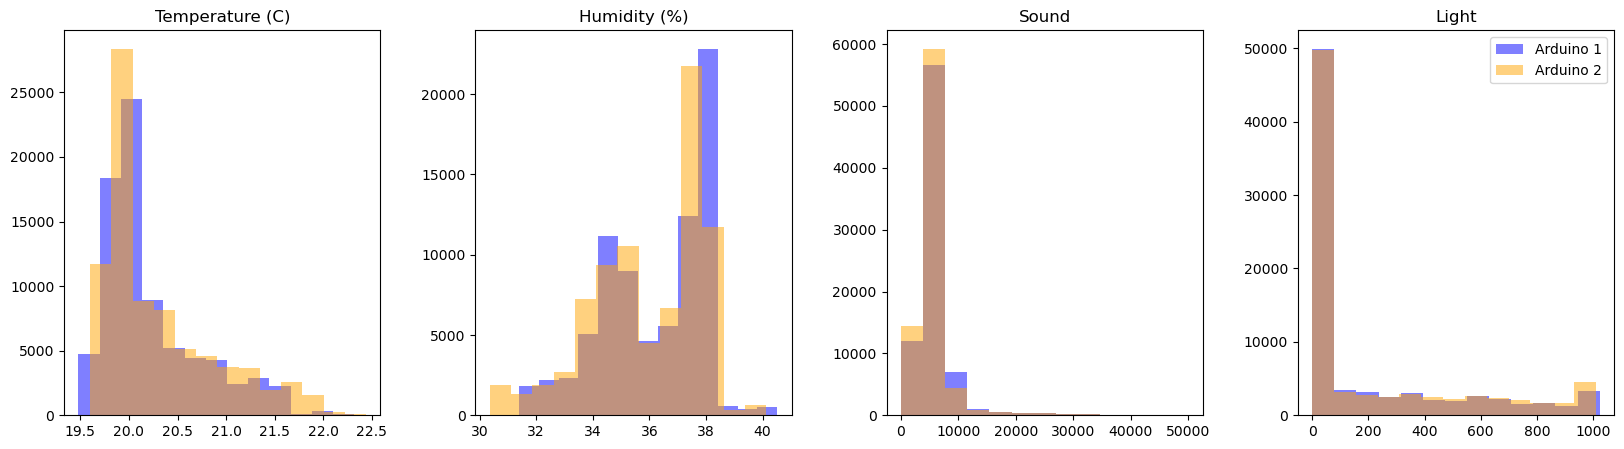

In [7]:
fig, ax = plt.subplots(1, 4, figsize=(20, 5))

dfs[0].hist(bins=13, ax=ax[:len(dfs[0].columns)], alpha=0.5, label='Arduino 1', color='blue', grid=False)
dfs[1].hist(bins=13, ax=ax[:len(dfs[1].columns)], alpha=0.5, label='Arduino 2', color='orange', grid=False)

plt.legend()

Text(0.5, 1.0, 'Temperature')

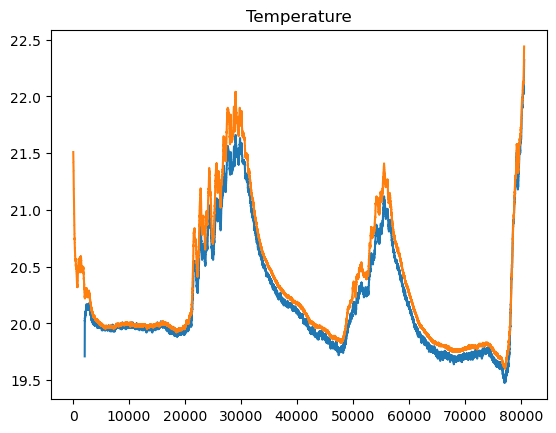

In [8]:
[df["Temperature (C)"].plot() for df in dfs]
plt.title("Temperature")

Text(0.5, 1.0, 'Humidity')

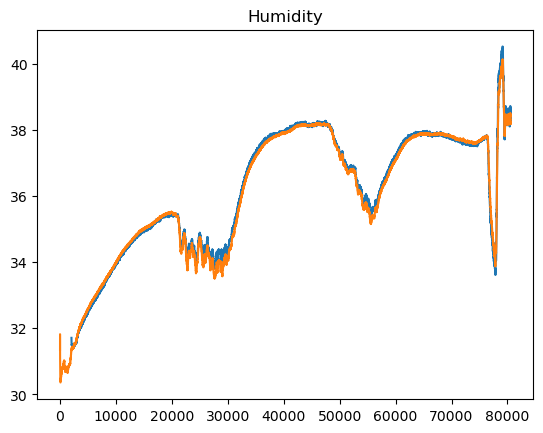

In [9]:
[df["Humidity (%)"].plot() for df in dfs]
plt.title("Humidity")

Text(0.5, 1.0, 'Sound')

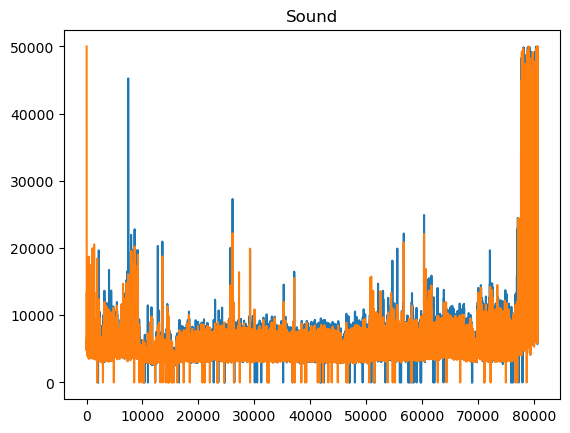

In [79]:
[df["Sound"].plot() for df in dfs]
plt.title("Sound")

Text(0.5, 1.0, 'Light')

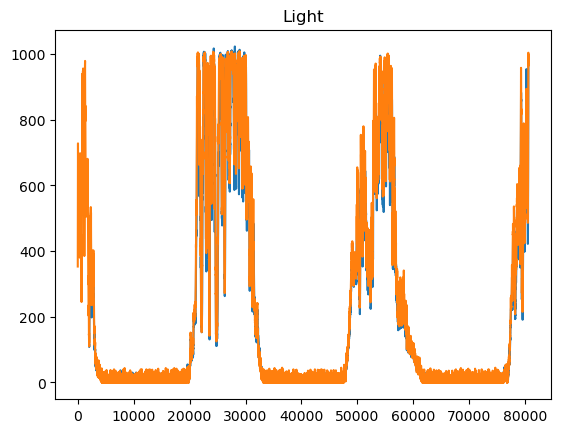

In [80]:
[df["Light"].plot() for df in dfs]
plt.title("Light")

In [88]:
abs(dfs[0]["Sound"].mean() - dfs[1]["Sound"].mean())

np.float64(352.75753095189975)

Text(0, 0.5, 'Sound level')

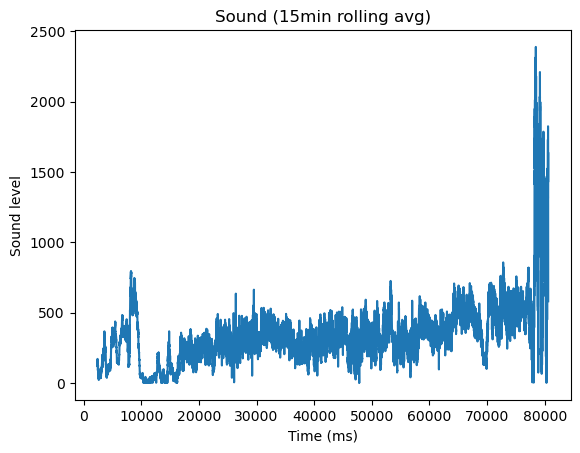

In [14]:
(dfs[0]["Sound"].rolling(300).mean() - dfs[1]["Sound"].rolling(300).mean()).abs().plot()
plt.title("Sound (15min rolling avg)")
plt.xlabel("Time (ms)")
plt.ylabel("Sound level")

In [45]:
night = [
    df.iloc[20000:50000]
      .copy()
      .reset_index(drop=True)
      ["Sound"]
      .loc[lambda x: (x >= 3000) & (x <= 10000)]
      .rolling(200)
      .mean()
    for df in corrected # dfs vs corrected gir veldig ulike resultater
]

[<Axes: >, <Axes: >]

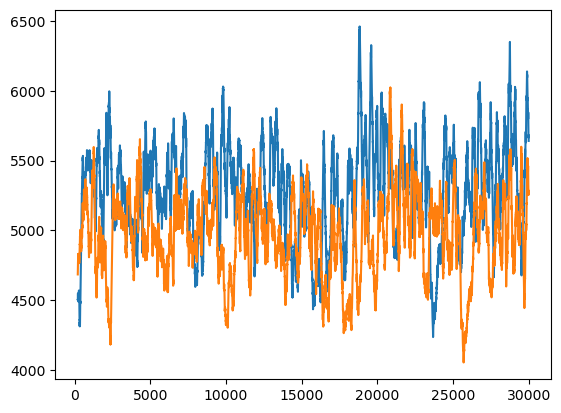

In [42]:
[x.plot() for x in night]

In [43]:
abs(night[1].mean() - night[0].mean())

np.float64(321.79450492549495)

Text(0.5, 1.0, 'Lydnivå i intervallet $\\left[ 20\\,000, 50\\,000 \\right]$ (15m gjennomsnitt)')

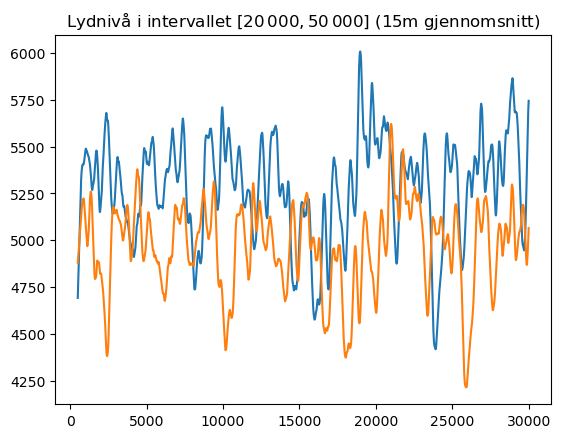

In [40]:
[x.rolling(300).mean().plot() for x in night]
plt.title(r"Lydnivå i intervallet $\left[ 20\,000, 50\,000 \right]$ (15m gjennomsnitt)")

In [20]:
((night[0] - night[1]) ** 2).mean() ** 0.5

np.float64(553.4408248212127)

In [46]:
night[0].corr(night[1])

np.float64(0.9857182550092554)

Ser at det tilsynelatende er ganske stor variasjon, men hvis jeg ser på grafene er de mye mer lik hverandre enn tallene ser ut til å si. Dette er nesten garantert fordi klokkene mellom de to arduinoene ikke er synkronisert, slik at verdiene er mye nærmere hverandre, men forskjøvet med noen sekunder.

In [31]:
parameter = "Light"
sig1 = dfs[0][parameter] - dfs[0][parameter].mean()
sig2 = dfs[1][parameter] - dfs[1][parameter].mean()

corr = signal.correlate(sig1, sig2, mode='full')

lags = signal.correlation_lags(len(sig1), len(sig2), mode='full')
best_lag = lags[np.argmax(corr)]

corrected = [dfs[0].copy(), dfs[1].shift(periods=best_lag)]

[<Axes: >, <Axes: >]

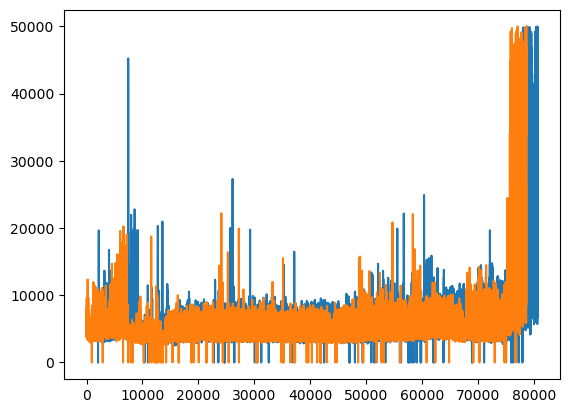

In [159]:
[df["Sound"].plot() for df in corrected]